# Redshifting check

The goal of this notebook is to produce a reliable function for transforming apparent magnitudes observed for objects at one redshift to the magnitudes that would be observed if the object were at a different redshift. Along the way it demonstrates some approaches (and pitfalls) to calculating magnitudes when shifting objects around in redshift. It should serve as a useful reference for how to do this sort of thing in the future. 

I redefine many variables during the course of this ~~novel~~ notebook, so be wary about running cells out of order!

TLDR; A function that does the job is implemented at the bottom of this notebook.

In [ ]:
import os

import kcorrect
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.cosmology import FlatLambdaCDM
from astropy.table import Table
from scipy.ndimage import gaussian_filter
from scipy.optimize import root_scalar

I happen to have [ezgal](http://www.baryons.org/ezgal/) installed for another project, so I'll use that. (Note that I have tweaked [my copy of the ezgal code](https://github.com/IntraClusterLight/nicl/tree/main/nicl/ezgal) a little, so that it works with recent versions of python). I'll focus on using ezgal, but one could also make use of some similar functionality in [speclite](https://github.com/desihub/speclite), [synphot](https://synphot.readthedocs.io/), etc.

In [ ]:
from nicl import ezgal

Let's create an SED for a simple stellar population formed at z=3, which is observed at z=0.9.

In [ ]:
model = ezgal.model("bc03_ssp_z_0.02_chab.model")
model.set_cosmology(Om=0.3, Ol=0.7, h=0.70, w=-1)
zf = 3.0
ztrue = 0.9

Add the filters we will use to the model. I am using filter curves from [speclite](https://speclite.readthedocs.io/en/latest/filters.html) which I have dropped into the folder where ezgal looks. Ezgal can read the ecsv files directly.

In [ ]:
filters = {
    "u": "lsst2023-u.ecsv",
    "g": "lsst2023-g.ecsv",
    "r": "lsst2023-r.ecsv",
    "VIS": "Euclid-VIS.ecsv",
    "i": "lsst2023-i.ecsv",
    "z": "lsst2023-z.ecsv",
    "y": "lsst2023-y.ecsv",
    "Y": "Euclid-Y.ecsv",
    "J": "Euclid-J.ecsv",
    "H": "Euclid-H.ecsv",
}
for name in filters:
    model.add_filter(
        filters[name], name=name, units="nm" if "lsst" in filters[name] else "a"
    )

Ezgal's normalisation doesn't seem to be applied consistently, so we do it ourselves.


In [ ]:
# model.set_normalization("VIS", ztrue, -22, apparent=False)

Create the restframe SED and normalize it to unit maximum and smooth for plotting purposes. The redshifts are only used here to determine the age of the stellar population.

In [ ]:
sed_restframe = model.get_sed(model.get_age(zf, ztrue), units="Fl")
sed_restframe = gaussian_filter(sed_restframe, 10)
wl_restframe = model.ls
sed_norm = sed_restframe.max()
sed_restframe /= sed_norm

## Visualise the SED and filters

This function transforms a restframe SED to the observed frame for a given redshift. Note that this transformation preserves total bolometric flux. Cosmological distance effects are not applied.

In [ ]:
def redshift_sed(wl_restframe, flam_restframe, z):
    flam_observed = flam_restframe / (1 + z)
    wl_observed = wl_restframe * (1 + z)
    return wl_observed, flam_observed

Make a pretty plot of the SEDs and filter curves, in a way we can add too later.

In [ ]:
def plot_sed(filters, wl_restframe, flam_restframe, z):
    fig, tr_ax = plt.subplots(figsize=(12, 6))
    sed_ax = tr_ax.twinx()
    sed_ax.plot(wl_restframe, flam_restframe, "w", lw=3, zorder=1)
    sed_ax.plot(wl_restframe, flam_restframe, "lightgray", label="restframe", zorder=2)
    wl_observed, flam_observed = redshift_sed(wl_restframe, flam_restframe, z)
    # sed_ax.plot(wl_restframe, sed_evolved, "gray", ls=":", label="evolved")
    sed_ax.plot(wl_observed, flam_observed, "w", lw=3, zorder=1)
    sed_ax.plot(wl_observed, flam_observed, "k", label="observed", zorder=2)
    sed_ax.set_xlim(xmin=3e3, xmax=2.2e4)
    sed_ax.set_ylim(ymin=0, ymax=1.05)
    sed_ax.set_xscale("log")
    cmap_norm = mpl.colors.LogNorm(vmin=3.5e3, vmax=1.8e4)
    cmap = mpl.colormaps["gist_rainbow_r"]
    for i, name in enumerate(filters):
        f = model.filters[name]
        c = cmap(cmap_norm(f.mean))
        h = "////" if i % 2 == 0 else r"\\\\"
        tr_ax.plot(f.ls, f.tran_ls, color=c, label=name, zorder=2)
        tr_ax.fill_between(f.ls, 0, f.tran_ls, color=c, zorder=1, alpha=0.1, hatch=h)
    tr_ax.axhline(0, color="w", zorder=3)
    tr_ax.set_ylim(ymin=0, ymax=1)
    tr_ax.set_xlabel(r"wavelength, $\lambda$ (Ångstrom)")
    sed_ax.set_ylabel(r"flux density, $f_\lambda$ (arbitrary normalisation)")
    tr_ax.set_ylabel("transmission")
    sed_ax.legend(loc="upper right")
    tr_ax.legend(loc="upper left")
    return sed_ax, tr_ax, cmap_norm, cmap

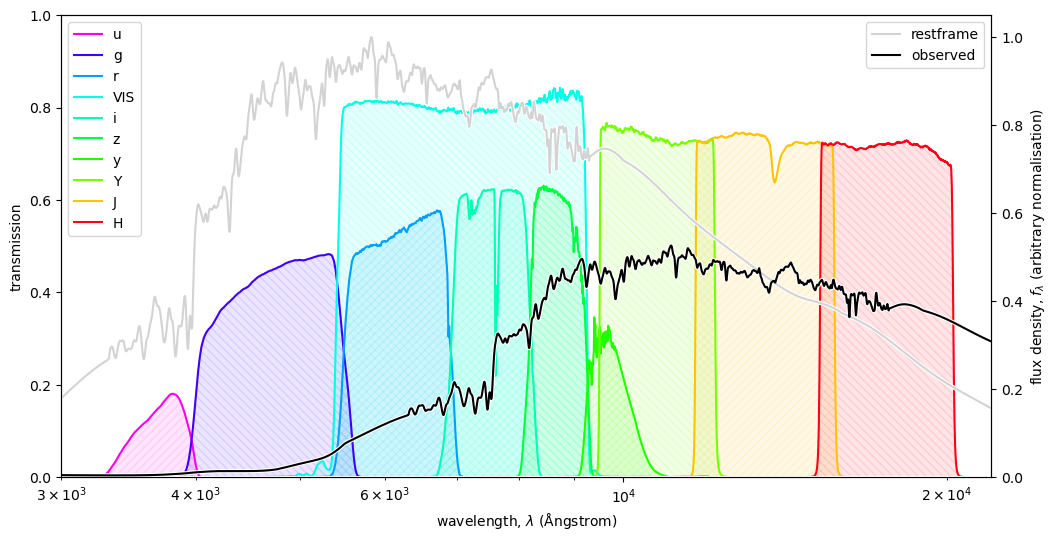

In [ ]:
plot_sed(model.filters, wl_restframe, sed_restframe, ztrue);

## Synthetic photometry

Using this SED, we can calculate apparent/absolute and restframe/observed photometry for the same SED observed at different redshifts, e.g. `zs`.

In [ ]:
zs = [0.3, 0.6, 0.9, 1.2, 1.5, 1.8]

Just so the numbers look sensible, we normalise the restframe VIS absolute magnitude of the SED to -22, which is roughly M*. When plotting we will further normalise so that the maximum of the smoothed restframe SED is unity.

In [ ]:
absmag_norm = -22

First, we'll use the main ezgal functions: `get_absolute_mags`, `get_observed_absolute_mags` and `get_apparent_mags`. Although they don't do quite what we want, we can use them to check we are doing things correctly later on. *If you are want to cut to the chase, you can scroll down to "**The better way**".*

Let's compute the absolute restframe magnitudes for the galaxy at `ztrue`.

In [ ]:
absmags_restframe_check = pd.DataFrame(
    model.get_absolute_mags(zf=zf, zs=ztrue), index=[ztrue], columns=filters
)
norm_check = absmag_norm - absmags_restframe_check.loc[ztrue, "VIS"]
absmags_restframe_check += norm_check
absmags_restframe_check

,u,g,r,VIS,i,z,y,Y,J,H
0.9,-19.568186,-21.074168,-21.749106,-22.0,-22.095625,-22.291412,-22.490764,-22.571359,-22.693637,-22.808013


Note that if we were to do 
```
absmags_restframe_check = pd.DataFrame(model.get_absolute_mags(zf=zf, zs=zs), index=zs, columns=filters)
```
the model would have different ages, and hence a different restframe SED, at each observed redshift.

Now we compute the observed-frame absolute magnitudes, i.e. if the spectrum were redshifted to `ztrue` (as shown in the plot above), but without cosmological distance effects. Again, we must specify `zs=ztrue`, as otherwise the SED would correspond to different age populations.

In [ ]:
absmags_observed_check = pd.DataFrame(
    model.get_observed_absolute_mags(zf=zf, zs=ztrue), index=[ztrue], columns=filters
)
absmags_observed_check += norm_check
absmags_observed_check

,u,g,r,VIS,i,z,y,Y,J,H
0.9,-15.339138,-17.38247,-19.690426,-20.774012,-20.780471,-21.653719,-21.988848,-22.254707,-22.700686,-23.103712


We can see that this makes qualitative sense by looking at the plot above. The J magnitude doesn't change, since in the J-band the SED has the same level before and after redshifting. The observed-frame magnitude is brighter than in restframe for the K-band, while it is fainter for all other bands, and especially in u and g.

We can include the distance modulus to get the apparent restframe magnitude, although it isn't particularly useful.

In [ ]:
dist_mod_ztrue = model.get_distance_moduli(ztrue)
appmags_restframe_check = absmags_restframe_check + dist_mod_ztrue
appmags_restframe_check

,u,g,r,VIS,i,z,y,Y,J,H
0.9,24.249445,22.743463,22.068525,21.817631,21.722005,21.526219,21.326867,21.246271,21.123994,21.009617


The observed-frame apparent magnitude is calculated as follows. Again, we must specify `zs=ztrue`, as otherwise the SED would correspond to different age populations.

In [ ]:
appmags_observed_check = pd.DataFrame(
    model.get_apparent_mags(zf=zf, zs=ztrue), index=[ztrue], columns=filters
)
appmags_observed_check += norm_check
appmags_observed_check

,u,g,r,VIS,i,z,y,Y,J,H
0.9,28.478493,26.435161,24.127205,23.043619,23.03716,22.163912,21.828783,21.562923,21.116945,20.713919


Check for consistency by simply applying the distance modulus to the observed-frame absolute magnitudes.

In [ ]:
absmags_observed_check + dist_mod_ztrue

,u,g,r,VIS,i,z,y,Y,J,H
0.9,28.478493,26.435161,24.127205,23.043619,23.03716,22.163912,21.828783,21.562923,21.116945,20.713919


Above we had the issue that the `ezgal.model` methods _evolve_ the model between different redshifts, but we want the restframe SED to stay fixed. To address this, we can figure out the formation redshifts required for the model to be the same age at different observed redshifts, and hence for the restframe SED to be identical.

In [ ]:
def find_zf_for_age(zf, ztrue, zs):
    nominal_age = model.get_age(zf, ztrue)

    def f(zf, zs):
        return model.get_age(zf, zs) - nominal_age

    newzf = root_scalar(
        f,
        bracket=[0, 10],
        args=zs,
    )
    return newzf.root

Try it out for `z=0.3`.

In [ ]:
z = 0.3
newzf = find_zf_for_age(zf, ztrue, z)
newzf

0.9416988667430648

In [ ]:
absmags_restframe_new = pd.DataFrame(
    model.get_absolute_mags(zf=newzf, zs=z), index=[z], columns=filters
)
absmags_restframe_new += norm_check
absmags_restframe_new

,u,g,r,VIS,i,z,y,Y,J,H
0.3,-19.568186,-21.074168,-21.749106,-22.0,-22.095625,-22.291412,-22.490764,-22.571359,-22.693637,-22.808013


This matches the absolute restframe magnitudes computed above, even though the observed redshift has changed, because we have changed the formation redshift such that the SEDs correspond to the same age.

In [ ]:
absmags_restframe_check

,u,g,r,VIS,i,z,y,Y,J,H
0.9,-19.568186,-21.074168,-21.749106,-22.0,-22.095625,-22.291412,-22.490764,-22.571359,-22.693637,-22.808013


We can also calculate the observed-frame apparent magnitudes for the fixed restframe SED observed at different redshifts. However, we run into a problem: for high observed redshifts we would need a formation redshift before the start of the Universe. Here we limit to those we can calculate with this approach.

In [ ]:
appmags_observed_fudge = pd.DataFrame(
    [
        model.get_apparent_mags(zf=find_zf_for_age(zf, ztrue, z), zs=z)[0]
        for z in zs[:4]
    ],
    index=zs[:4],
    columns=filters,
)
appmags_observed_fudge += norm_check
appmags_observed_fudge

,u,g,r,VIS,i,z,y,Y,J,H
0.3,22.735926,20.972417,19.592126,19.197447,19.047080,18.795990,18.580912,18.433036,18.134679,17.980304
0.6,26.285682,23.807928,22.261704,21.403453,21.165038,20.783366,20.501009,20.327918,19.950634,19.645619
0.9,28.478493,26.435161,24.127205,23.043619,23.037160,22.163912,21.828783,21.562923,21.116945,20.713919
1.2,29.721477,28.334265,25.888145,24.596410,24.478248,23.737537,22.936869,22.555331,21.993130,21.551666


## The better way

The above appears to (partly) achieve what we want, but there is a better approach. We can use `astro_filter.calc_mag` to get the absolute magnitude from a redshifted SED. This corresponds to absmag_observed above; the spectrum is redshifted to `z`, but without cosmological distance effects. Here, however, we can use arbitrary `z`, without changing the restframe SED.

In [ ]:
absmags_restframe = pd.DataFrame()
for f in model.filters:
    absmags_restframe.loc[ztrue, f] = model.filters[f].calc_mag(
        model.vs, model.get_sed(model.get_age(zf, ztrue)), z=0.0
    )
norm = absmag_norm - absmags_restframe.loc[ztrue, "VIS"]
absmags_restframe += norm
absmags_restframe

,u,g,r,VIS,i,z,y,Y,J,H
0.9,-19.568186,-21.074168,-21.749106,-22.0,-22.095625,-22.291412,-22.490764,-22.571359,-22.693637,-22.808013


As one would hope, this is the same as above.

In [ ]:
absmags_restframe_check

,u,g,r,VIS,i,z,y,Y,J,H
0.9,-19.568186,-21.074168,-21.749106,-22.0,-22.095625,-22.291412,-22.490764,-22.571359,-22.693637,-22.808013


In [ ]:
appmags_restframe = absmags_restframe + dist_mod_ztrue
appmags_restframe

,u,g,r,VIS,i,z,y,Y,J,H
0.9,24.249445,22.743463,22.068525,21.817631,21.722005,21.526219,21.326867,21.246271,21.123994,21.009617


Now there is nothing to stop us from transforming exactly the same SED to arbitrary redshifts and calculating the magnitude in the observed-frame.

In [ ]:
absmags_observed = pd.DataFrame()
sed = model.get_sed(model.get_age(zf, ztrue))
for f in model.filters:
    for z in zs:
        absmags_observed.loc[z, f] = model.filters[f].calc_mag(model.vs, sed, z)
absmags_observed += norm
absmags_observed

,u,g,r,VIS,i,z,y,Y,J,H
0.3,-18.219517,-19.983026,-21.363316,-21.757996,-21.908362,-22.159452,-22.374530,-22.522406,-22.820763,-22.975138
0.6,-16.453293,-18.931046,-20.477270,-21.335521,-21.573936,-21.955608,-22.237965,-22.411056,-22.788340,-23.093355
0.9,-15.339138,-17.382470,-19.690426,-20.774012,-20.780471,-21.653719,-21.988848,-22.254707,-22.700686,-23.103712
1.2,-14.868538,-16.255750,-18.701870,-19.993605,-20.111768,-20.852478,-21.653147,-22.034684,-22.596886,-23.038350
1.5,-14.839479,-15.578762,-17.435342,-19.328506,-19.431281,-20.307378,-20.880183,-21.644644,-22.460207,-22.973678
1.8,-14.972925,-14.912046,-16.637420,-18.627047,-18.308535,-19.798900,-20.432274,-21.056274,-22.254226,-22.890076


Applying the distance modulus gets us observed-frame apparent magnitudes.

In [ ]:
dist_mod = pd.DataFrame(model.get_distance_moduli(zs), index=zs, columns=filters)
dist_mod

,u,g,r,VIS,i,z,y,Y,J,H
0.3,40.955442,40.955442,40.955442,40.955442,40.955442,40.955442,40.955442,40.955442,40.955442,40.955442
0.6,42.738974,42.738974,42.738974,42.738974,42.738974,42.738974,42.738974,42.738974,42.738974,42.738974
0.9,43.817631,43.817631,43.817631,43.817631,43.817631,43.817631,43.817631,43.817631,43.817631,43.817631
1.2,44.590016,44.590016,44.590016,44.590016,44.590016,44.590016,44.590016,44.590016,44.590016,44.590016
1.5,45.189034,45.189034,45.189034,45.189034,45.189034,45.189034,45.189034,45.189034,45.189034,45.189034
1.8,45.676611,45.676611,45.676611,45.676611,45.676611,45.676611,45.676611,45.676611,45.676611,45.676611


In [ ]:
appmags_observed = absmags_observed + dist_mod
appmags_observed

,u,g,r,VIS,i,z,y,Y,J,H
0.3,22.735926,20.972417,19.592126,19.197447,19.047080,18.795990,18.580912,18.433036,18.134679,17.980304
0.6,26.285682,23.807928,22.261704,21.403453,21.165038,20.783366,20.501009,20.327918,19.950634,19.645619
0.9,28.478493,26.435161,24.127205,23.043619,23.037160,22.163912,21.828783,21.562923,21.116945,20.713919
1.2,29.721477,28.334265,25.888145,24.596410,24.478248,23.737537,22.936869,22.555331,21.993130,21.551666
1.5,30.349555,29.610272,27.753692,25.860528,25.757753,24.881657,24.308851,23.544390,22.728827,22.215356
1.8,30.703686,30.764565,29.039191,27.049565,27.368076,25.877711,25.244337,24.620337,23.422385,22.786535


We can see that this gives exactly the same result as using the more circuitous method above (which also doesn't work for high redshifts).

In [ ]:
appmags_observed_fudge

,u,g,r,VIS,i,z,y,Y,J,H
0.3,22.735926,20.972417,19.592126,19.197447,19.047080,18.795990,18.580912,18.433036,18.134679,17.980304
0.6,26.285682,23.807928,22.261704,21.403453,21.165038,20.783366,20.501009,20.327918,19.950634,19.645619
0.9,28.478493,26.435161,24.127205,23.043619,23.037160,22.163912,21.828783,21.562923,21.116945,20.713919
1.2,29.721477,28.334265,25.888145,24.596410,24.478248,23.737537,22.936869,22.555331,21.993130,21.551666


## Bringing in kcorrect

In the above we had a high-resolution SED, which we could redshift and convolve with the filter transmission curves to measure magnitudes. What if we only have observed magnitudes. In that case, we first need to infer an SED from the magnitudes, e.g. using kcorrect or prospector. Using that we can estimate restframe magnitudes. Finally, we can determine the k-correction for any other redshift and derive magnitudes that would be observed if the galaxy were at that redshift.

Copy the filter responses over for use by kcorrect.

In [ ]:
filter_names = []
for name, fn in filters.items():
    filt = model.filters[name]
    tab = Table(data={"wave": filt.ls, "pass": filt.tran_ls})
    fn = fn.replace(".ecsv", "")
    filter_names.append(fn)
    fn = os.path.join(kcorrect.KCORRECT_DIR, f"data/responses/{fn}.dat")
    if not os.path.exists(fn):
        tab.write(fn, format="ascii.fixed_width")

Use the same cosmology as above.

In [ ]:
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

### The simple, but slightly inaccurate, approach

Setup kcorrect. Here we are kcorrecting to the same band (not using `responses_out` and `responses_map`). Reduce the resolution of the redshift grid to speed this up.

In [ ]:
kc = kcorrect.kcorrect.Kcorrect(
    responses=filter_names, cosmo=cosmo, redshift_range=[0.0, 2.0], nredshift=201
)

First, we fit a superposition of templates to the photometry, with weights given by `coeffs`.  The choice of `ivar` just ensures the error is much smaller than any of the fluxes.

In [ ]:
def to_maggies(apparent_mag):
    return 10 ** (np.array(apparent_mag) / -2.5)


def from_maggies(maggies):
    return -2.5 * np.log10(maggies)


maggies = to_maggies(appmags_observed.loc[ztrue])
ivar = np.ones_like(maggies) / (maggies.min() / 1000) ** 2

coeffs = kc.fit_coeffs(redshift=ztrue, maggies=maggies, ivar=ivar)

We can use these to estimate the restframe SED. For plotting purposes, here we smooth and normalise the SED in the same manner as above.

In [ ]:
wl_restframe_kc = kc.templates.restframe_wave
sed_restframe_kc = coeffs.dot(kc.templates.restframe_flux)
sed_restframe_kc = gaussian_filter(sed_restframe_kc, 2)
sed_norm_kc = sed_restframe_kc.max()
sed_restframe_kc /= sed_norm_kc

We can transform the restframe SED to as observed at any redshift. Here we redshift back to `ztruez` for comparison with the observed SED that was used to generate the photometry given to kcorrect.

In [ ]:
wl_observed_kc, sed_observed_kc = redshift_sed(wl_restframe_kc, sed_restframe_kc, ztrue)

We can put the input photometry in the same units as the SED for plotting.

In [ ]:
def maggies_to_fluxes(maggies, norm):
    wl, flux = kcorrect.utils.maggies2flambda(maggies=maggies, responses=filter_names)
    flux /= norm
    return wl, flux


def mags_to_fluxes(mags, norm):
    maggies = to_maggies(mags)
    wl, flux = maggies_to_fluxes(maggies, norm)
    return wl, flux

In [ ]:
wl_mag, flux_mag = maggies_to_fluxes(maggies, sed_norm_kc)

We can also reconstruct the observed apparent magnitudes by convolving the redshifted kcorrect model SED with the filter curves. This could be done for any redshift, but here we use `ztrue` for comparison with the input photometry. 

In [ ]:
rmaggies = kc.reconstruct(redshift=ztrue, coeffs=coeffs)
wl_rmag, flux_rmag = maggies_to_fluxes(rmaggies, sed_norm_kc)

If we compare the input and reconstructed photometry, we see that it is generally good to better than 1%, but there is a substantial (~100%) discrepancy in the bluest bands. The kcorrect templates cannot perfectly match the "true" SED.

In [ ]:
(flux_rmag - flux_mag) / flux_mag

array([ 1.29516607e+00,  1.03518282e-01, -3.29317765e-02,  2.54894693e-03,
        1.05678301e-02,  3.71187468e-03, -1.08026119e-04, -2.10120958e-03,
       -2.47702945e-03,  1.24112709e-03])

The same can be done for the restframe kcorrect model SED and we can compare to the true restframe apparent magnitudes. These match well, as the discrepant blue area of the SED is redshifted out of the range of the filter set.

In [ ]:
rmaggies_restframe = kc.reconstruct(redshift=0, coeffs=coeffs)
wl_rf_rmag, flux_rf_rmag = maggies_to_fluxes(rmaggies_restframe, sed_norm_kc)

wl_rf_mag, flux_rf_mag = mags_to_fluxes(appmags_restframe.loc[ztrue], sed_norm)

In [ ]:
rmaggies_restframe = kc.reconstruct(redshift=0, coeffs=coeffs)
wl_rf_rmag, flux_rf_rmag = maggies_to_fluxes(rmaggies_restframe, sed_norm_kc)

wl_rf_mag, flux_rf_mag = mags_to_fluxes(appmags_restframe.loc[ztrue], sed_norm_kc)

In [ ]:
(flux_rf_rmag - flux_rf_mag) / flux_rf_mag

array([-0.00488437,  0.0020227 ,  0.00160188, -0.00488324, -0.00669404,
       -0.00752144,  0.00410055,  0.01335095,  0.01745932,  0.0348406 ])

We can also estimate the restframe magnitudes by a k-correction. The k-correction is determined from the difference between the reconstructed observed and restframe magnitudes. This is then applied as a correction to the input observed magnitude. Since the reconstructed observed-frame magnitude is discrepant, the k-correction is inaccurate and so the resulting restframe magnitudes do not match the true values. This is a case where it would be better to use a k-correction based on a better matching band, see later.

In [ ]:
absmags_restframe_kc = kc.absmag(
    redshift=ztrue, maggies=maggies, ivar=ivar, coeffs=coeffs
)
appmags_restframe_kc = absmags_restframe_kc + cosmo.distmod(ztrue).value

In [ ]:
wl_rf_kc_mag, flux_rf_kc_mag = mags_to_fluxes(appmags_restframe_kc, sed_norm_kc)

In [ ]:
(flux_rf_kc_mag - flux_rf_mag) / flux_rf_mag

array([-0.56642934, -0.09197381,  0.03571057, -0.00741046, -0.01707953,
       -0.01118882,  0.00421024,  0.01548587,  0.01998678,  0.03355894])

#### Going back to observed magnitudes

The last step is to complete the round-trip. We now have apparent restframe magnitudes, so can undo the k-correction to get observed magnitudes for any redshift we need. To check for consistency, we'll convert back to `ztrue`.

Below we demonstrate that the k-corrections are just the difference between the reconstructed observed-frame and restframe magnitudes.

In [ ]:
rmag = from_maggies(rmaggies)
rmag_restframe = from_maggies(rmaggies_restframe)
rmag - rmag_restframe

array([ 3.32169649,  3.58694335,  2.09677505,  1.21790945,  1.29644823,
        0.62547334,  0.50647645,  0.33333553,  0.01443615, -0.25986184])

In [ ]:
k_obsz = kc.kcorrect(redshift=ztrue, coeffs=coeffs)
k_obsz

array([ 3.32169649,  3.58694335,  2.09677505,  1.21790945,  1.29644823,
        0.62547334,  0.50647645,  0.33333553,  0.01443615, -0.25986184])

The output of kcorrect's `absmag` is simply the input observed magnitudes minus the distance modulus and the k-correction.

In [ ]:
appmags_observed.loc[[ztrue]] - cosmo.distmod(ztrue).value - k_obsz

,u,g,r,VIS,i,z,y,Y,J,H
0.9,-18.660852,-20.969431,-21.787219,-21.991939,-22.076937,-22.27921,-22.495342,-22.588061,-22.71514,-22.843868


In [ ]:
absmags_restframe_kc

array([-18.6608536 , -20.9694316 , -21.78721999, -21.99194204,
       -22.0769391 , -22.27921327, -22.49534326, -22.58806194,
       -22.71514073, -22.84386932])

So, if we have absolute restframe magnitudes we can just add the distance modulus and the k-correction to go back to apparent observed-frame magnitudes.

In [ ]:
appmags_observed_kc = appmags_restframe_kc + k_obsz

In [ ]:
wl_kc_mag, flux_kc_mag = mags_to_fluxes(appmags_observed_kc, sed_norm_kc)

The round-tripped magnitudes match the input photometry perfectly, and closely match the photometry reconstructed from the observed-frame SED model (with offsets in the blue as previously discussed).

In [ ]:
(flux_kc_mag - flux_mag) / flux_mag

array([1.05586921e-06, 7.96635088e-07, 9.03054825e-07, 2.85316171e-06,
       1.85761867e-06, 2.99264989e-06, 1.20284309e-06, 1.16054428e-06,
       9.11031663e-07, 1.08192241e-06])

In [ ]:
(flux_kc_mag - flux_rmag) / flux_rmag

array([-5.64301220e-01, -9.38067698e-02,  3.40541429e-02, -2.53962041e-03,
       -1.04554807e-02, -3.69516604e-03,  1.09240763e-04,  2.10679695e-03,
        2.48409366e-03, -1.23850802e-03])

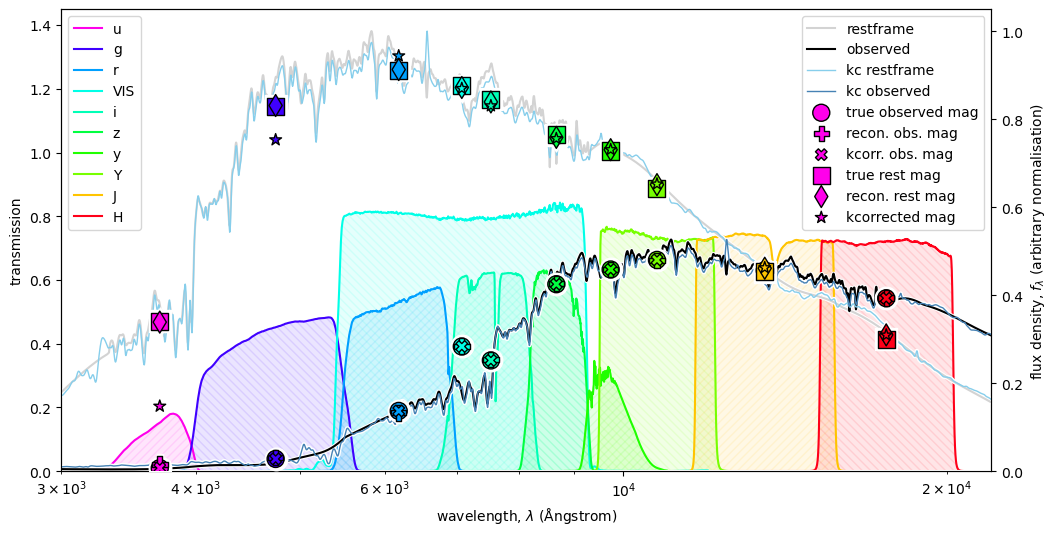

In [ ]:
def add_mag(ax, wl, flux, marker, label, s=125):
    ax.scatter(wl, flux, c="w", marker=marker, s=s * 1.75, zorder=5)
    ax.scatter(
        wl,
        flux,
        c=wl,
        edgecolors="k",
        marker=marker,
        s=s,
        norm=cmap_norm,
        cmap=cmap,
        zorder=6,
        label=label,
    )


def add_sed(ax, wl, flux, color, label, ls="-", lw=1):
    ax.plot(wl, flux, color="w", lw=3 * lw, zorder=1)
    ax.plot(wl, flux, color=color, label=label, zorder=2, ls=ls, lw=lw)


sed_ax, tr_ax, cmap_norm, cmap = plot_sed(
    model.filters, wl_restframe, sed_restframe, ztrue
)

add_sed(sed_ax, wl_restframe_kc, sed_restframe_kc, "skyblue", "kc restframe")
add_sed(sed_ax, wl_observed_kc, sed_observed_kc, "steelblue", "kc observed")

add_mag(sed_ax, wl_mag, flux_mag, "o", "true observed mag", s=150)
add_mag(sed_ax, wl_rmag, flux_rmag, "P", "recon. obs. mag")
add_mag(sed_ax, wl_kc_mag, flux_kc_mag, "X", "kcorr. obs. mag", s=70)

add_mag(sed_ax, wl_rf_mag, flux_rf_mag, "s", "true rest mag", s=150)
add_mag(sed_ax, wl_rf_rmag, flux_rf_rmag, "d", "recon. rest mag")
add_mag(sed_ax, wl_rf_kc_mag, flux_rf_kc_mag, "*", "kcorrected mag", s=80)

tr_ax.set_ylim(ymax=1.45)
sed_ax.legend();

### Mapping the filters

Let's do it again, but this time setup kcorrect so that it maps the k-corrections better. The responses map specifies which observed-frame band to map to each restframe band.

In [ ]:
filter_map = [2, 3, 4, 5, 6, 7, 8, 9, 9, 9]
responses_map = [filter_names[i] for i in filter_map]
print(responses_map)

['lsst2023-r', 'Euclid-VIS', 'lsst2023-i', 'lsst2023-z', 'lsst2023-y', 'Euclid-Y', 'Euclid-J', 'Euclid-H', 'Euclid-H', 'Euclid-H']


First, we fit a superposition of templates to the photometry, with weights given by `coeffs`.  The choice of `ivar` just ensures the error is much smaller than any of the fluxes.

In [ ]:
kc_mapped = kcorrect.kcorrect.Kcorrect(
    responses=filter_names,
    cosmo=cosmo,
    responses_map=responses_map,
    redshift_range=[0.0, 2.0],
    nredshift=201,
)

In [ ]:
maggies = to_maggies(appmags_observed.loc[ztrue])
ivar = np.ones_like(maggies) / (maggies.min() / 1000) ** 2

coeffs_mapped = kc_mapped.fit_coeffs(redshift=ztrue, maggies=maggies, ivar=ivar)

We can use these to estimate the restframe SED. For plotting purposes, here we smooth and normalise the SED in the same manner as above.

In [ ]:
wl_restframe_kc = kc_mapped.templates.restframe_wave
sed_restframe_kc = coeffs_mapped.dot(kc_mapped.templates.restframe_flux)
sed_restframe_kc = gaussian_filter(sed_restframe_kc, 2)
sed_norm_kc = sed_restframe_kc.max()
sed_restframe_kc /= sed_norm_kc

We can transform the restframe SED to as observed at any redshift. Here we redshift back to `ztruez` for comparison with the observed SED that was used to generate the photometry given to kcorrect.

In [ ]:
wl_observed_kc, sed_observed_kc = redshift_sed(wl_restframe_kc, sed_restframe_kc, ztrue)

We can put the input photometry in the same units as the SED for plotting.

In [ ]:
wl_mag, flux_mag = maggies_to_fluxes(maggies, sed_norm_kc)

We can also reconstruct the observed apparent magnitudes by convolving the redshifted kcorrect model SED with the filter curves. This could be done for any redshift, but here we use `ztrue` for comparison with the input photometry. 

In [ ]:
rmaggies = kc_mapped.reconstruct(redshift=ztrue, coeffs=coeffs_mapped)
wl_rmag, flux_rmag = maggies_to_fluxes(rmaggies, sed_norm_kc)

If we compare the input and reconstructed photometry, we see that it is generally good to better than 1%, but there is a substantial (~100%) discrepancy in the bluest bands. The kcorrect templates cannot perfectly match the "true" SED.

In [ ]:
(flux_rmag - flux_mag) / flux_mag

array([ 1.29516607e+00,  1.03518282e-01, -3.29317765e-02,  2.54894693e-03,
        1.05678301e-02,  3.71187468e-03, -1.08026119e-04, -2.10120958e-03,
       -2.47702945e-03,  1.24112709e-03])

The same can be done for the restframe kcorrect model SED and we can compare to the true restframe apparent magnitudes. These match well, as the discrepant blue area of the SED is redshifted out of the range of the filter set.

In [ ]:
rmaggies_restframe = kc_mapped.reconstruct(redshift=0, coeffs=coeffs_mapped)
wl_rf_rmag, flux_rf_rmag = maggies_to_fluxes(rmaggies_restframe, sed_norm_kc)

wl_rf_mag, flux_rf_mag = mags_to_fluxes(appmags_restframe.loc[ztrue], sed_norm_kc)

In [ ]:
(flux_rf_rmag - flux_rf_mag) / flux_rf_mag

array([-0.00488437,  0.0020227 ,  0.00160188, -0.00488324, -0.00669404,
       -0.00752144,  0.00410055,  0.01335095,  0.01745932,  0.0348406 ])

We can also estimate the restframe magnitudes by a k-correction. The k-correction is determined from the difference between the reconstructed observed and restframe magnitudes. This is then applied as a correction to the input observed magnitude. Unlike before, these observed and restframe bands aren't the same. Instead, they are chosen to sample roughly the same region of the SED. As a result, the kcorrected magnitudes agree much better with the true values.

In [ ]:
absmags_restframe_kc = kc_mapped.absmag(
    redshift=ztrue, maggies=maggies, ivar=ivar, coeffs=coeffs_mapped
)
appmags_restframe_kc = absmags_restframe_kc + cosmo.distmod(ztrue).value

In [ ]:
wl_rf_kc_mag, flux_rf_kc_mag = mags_to_fluxes(appmags_restframe_kc, sed_norm_kc)

In [ ]:
(flux_rf_kc_mag - flux_rf_mag) / flux_rf_mag

array([ 0.02900344, -0.00052205, -0.00887035, -0.00856036, -0.00658553,
       -0.00543049,  0.00659483,  0.0120959 ,  0.01619919,  0.03355894])

#### Going back to observed magnitudes

The last step is to complete the round-trip. We now have apparent restframe magnitudes, so can undo the k-correction to get observed magnitudes for any redshift we need. To check for consistency, we'll convert back to `ztrue`.

Below we demonstrate that the k-corrections are just the difference between the `filter_map` reconstructed observed-frame and the restframe magnitudes.

In [ ]:
rmag_restframe = from_maggies(rmaggies_restframe)
rmag[filter_map] - rmag_restframe

array([-0.09119901,  0.29958611,  0.95895926,  0.33694357,  0.09960255,
        0.03079129, -0.20278619, -0.51929976, -0.39262968, -0.25986184])

In [ ]:
k_obsz = kc_mapped.kcorrect(redshift=ztrue, coeffs=coeffs_mapped)
k_obsz

array([-0.09119901,  0.29958611,  0.95895926,  0.33694357,  0.09960255,
        0.03079129, -0.20278619, -0.51929976, -0.39262968, -0.25986184])

The output of kcorrect's `absmag` is simply the input observed magnitudes minus the distance modulus and the k-correction. Because we used `responses_map`, the k-corrections need to be applied to the correct restframe magnitudes, using `filter_map`.

In [ ]:
appmags_observed.loc[ztrue].values[filter_map] - cosmo.distmod(ztrue).value - k_obsz

array([-19.59924495, -21.0736156 , -21.73944812, -21.99068025,
       -22.08846805, -22.28551644, -22.4979174 , -22.58443022,
       -22.7111003 , -22.84386814])

In [ ]:
absmags_restframe_kc

array([-19.59924593, -21.0736187 , -21.73945014, -21.9906835 ,
       -22.08846936, -22.2855177 , -22.49791838, -22.58443139,
       -22.71110147, -22.84386932])

So, if we have absolute restframe magnitudes we can just add the distance modulus and the k-correction to go back to apparent observed-frame magnitudes. However, we only get observed magnitudes in the bands specified by the response mapping (note the column names below).

In [ ]:
appmags_observed_kc = absmags_restframe_kc + cosmo.distmod(ztrue).value + k_obsz
appmags_observed_kc = pd.DataFrame(
    [appmags_observed_kc],
    index=[ztrue],
    columns=[list(filters.keys())[i] for i in filter_map],
)
appmags_observed_kc

,r,VIS,i,z,y,Y,J,H,H,H
0.9,24.127204,23.043616,23.037158,22.163909,21.828782,21.562922,21.116944,20.713917,20.713917,20.713917


In [ ]:
appmags_observed.loc[[ztrue]]

,u,g,r,VIS,i,z,y,Y,J,H
0.9,28.478493,26.435161,24.127205,23.043619,23.03716,22.163912,21.828783,21.562923,21.116945,20.713919


Maybe we can live without the full set of filters, since we have the Euclid ones. However, that might not always be the case, depending on the `ztrue` and the redshift we are transforming to. If we want the full set of filters, we can calculate the kcorrections ourselves, using the fact that the k-corrections are just the difference between the reconstructed observed-frame and the restframe magnitudes. Because we are working backwards, we need to pick the restframe magnitude that corresponds to each observed-frame magnitude.

In [ ]:
filter_remap = [0, 0, 0, 1, 2, 3, 4, 5, 6, 7]
[list(filters.keys())[i] for i in filter_remap]

['u', 'u', 'u', 'g', 'r', 'VIS', 'i', 'z', 'y', 'Y']

In [ ]:
k_remap_obsz = rmag - rmag_restframe[filter_remap]
k_remap_obsz

array([ 3.32169649,  2.07345152, -0.09119901,  0.29958611,  0.95895926,
        0.33694357,  0.09960255,  0.03079129, -0.20278619, -0.51929976])

In [ ]:
appmags_observed_kc = (
    absmags_restframe_kc[filter_remap] + cosmo.distmod(ztrue).value + k_remap_obsz
)
appmags_observed_kc = pd.DataFrame(
    [appmags_observed_kc], index=[ztrue], columns=filters
)
appmags_observed_kc

,u,g,r,VIS,i,z,y,Y,J,H
0.9,27.540099,26.291854,24.127204,23.043616,23.037158,22.163909,21.828782,21.562922,21.116944,20.713917


In [ ]:
appmags_observed.loc[[ztrue]]

,u,g,r,VIS,i,z,y,Y,J,H
0.9,28.478493,26.435161,24.127205,23.043619,23.03716,22.163912,21.828783,21.562923,21.116945,20.713919


This has worked correctly, even though there is the usual discrepancy in the blue, because we are completely dependent on the kcorrect model SED when extrapolating from the restframe r-band magnitude.

We can actually get the same result directly out of kcorrect, if we create a new kcorrect object with the observed-frame filters we want as `responses_map` and the input restframe filters as `responses_out`. 

In [ ]:
responses_out = [filter_names[i] for i in filter_remap]
responses_remap = filter_names

In [ ]:
kc_remapped = kcorrect.kcorrect.Kcorrect(
    responses=filter_names,
    cosmo=cosmo,
    responses_map=responses_remap,
    responses_out=responses_out,
    redshift_range=[0.0, 2.0],
    nredshift=201,
)

In [ ]:
k_remap_obsz = kc_remapped.kcorrect(redshift=ztrue, coeffs=coeffs)
k_remap_obsz

array([ 3.32169649,  2.07345152, -0.09119901,  0.29958611,  0.95895926,
        0.33694357,  0.09960255,  0.03079129, -0.20278619, -0.51929976])

So the k-corrections match. Note that to apply these, we need to select the corresponding filters from our previously calculated absmags. However, could have just asked for these filters by specifying `response_out` in our first kcorrect object, but we also need to be careful to then change `response_map` so that it corresponds to the selected `response_out`.

In [ ]:
wl_kc_mag, flux_kc_mag = mags_to_fluxes(appmags_observed_kc, sed_norm_kc)

In [ ]:
(flux_kc_mag - flux_mag) / flux_mag

array([[1.37332598e+00, 1.41097651e-01, 9.03054825e-07, 2.85316171e-06,
        1.85761866e-06, 2.99264989e-06, 1.20284309e-06, 1.16054429e-06,
        9.11031663e-07, 1.08192241e-06]])

In [ ]:
(flux_kc_mag - flux_rmag) / flux_rmag

array([[ 0.03405414,  0.03405414,  0.03405414, -0.00253962, -0.01045548,
        -0.00369517,  0.00010924,  0.0021068 ,  0.00248409, -0.00123851]])

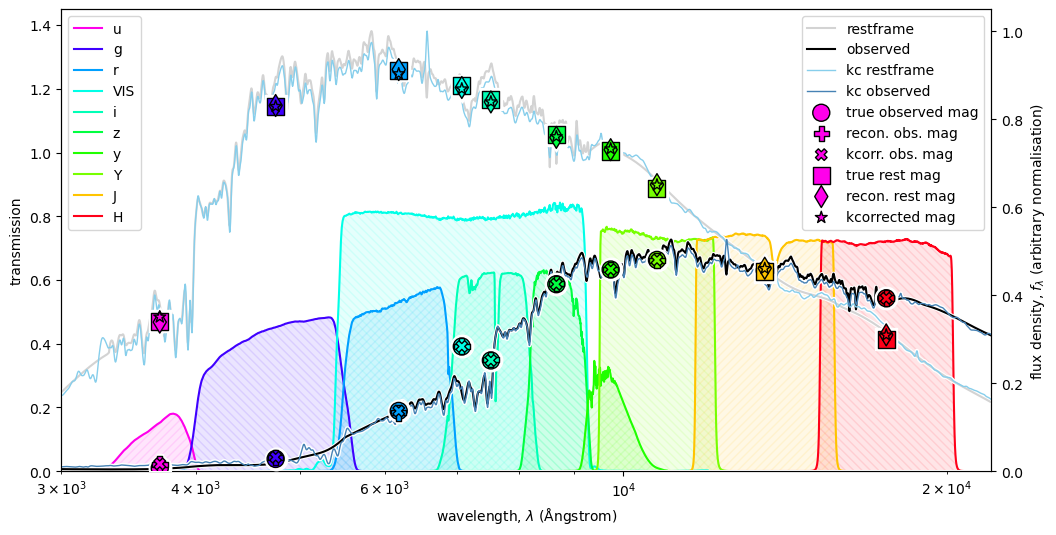

In [ ]:
sed_ax, tr_ax, cmap_norm, cmap = plot_sed(
    model.filters, wl_restframe, sed_restframe, ztrue
)

add_sed(sed_ax, wl_restframe_kc, sed_restframe_kc, "skyblue", "kc restframe")
add_sed(sed_ax, wl_observed_kc, sed_observed_kc, "steelblue", "kc observed")

add_mag(sed_ax, wl_mag, flux_mag, "o", "true observed mag", s=150)
add_mag(sed_ax, wl_rmag, flux_rmag, "P", "recon. obs. mag")
add_mag(sed_ax, wl_kc_mag, flux_kc_mag, "X", "kcorr. obs. mag", s=70)

add_mag(sed_ax, wl_rf_mag, flux_rf_mag, "s", "true rest mag", s=150)
add_mag(sed_ax, wl_rf_rmag, flux_rf_rmag, "d", "recon. rest mag")
add_mag(sed_ax, wl_rf_kc_mag, flux_rf_kc_mag, "*", "kcorrected mag", s=80)

tr_ax.set_ylim(ymax=1.45)
sed_ax.legend();

### Transforming observed magnitudes to another redshift

Above, we have figured out how to use kcorrect to take a round-trip from observed magnitudes of an object at `ztrue`, to restframe magnitudes, and back to observed magnitudes for the object at `ztrue`. Now let's change the final step to estimate the magnitudes that would be observed if the object were at some other redshift, `zobs`.

In [ ]:
zobs = 0.3

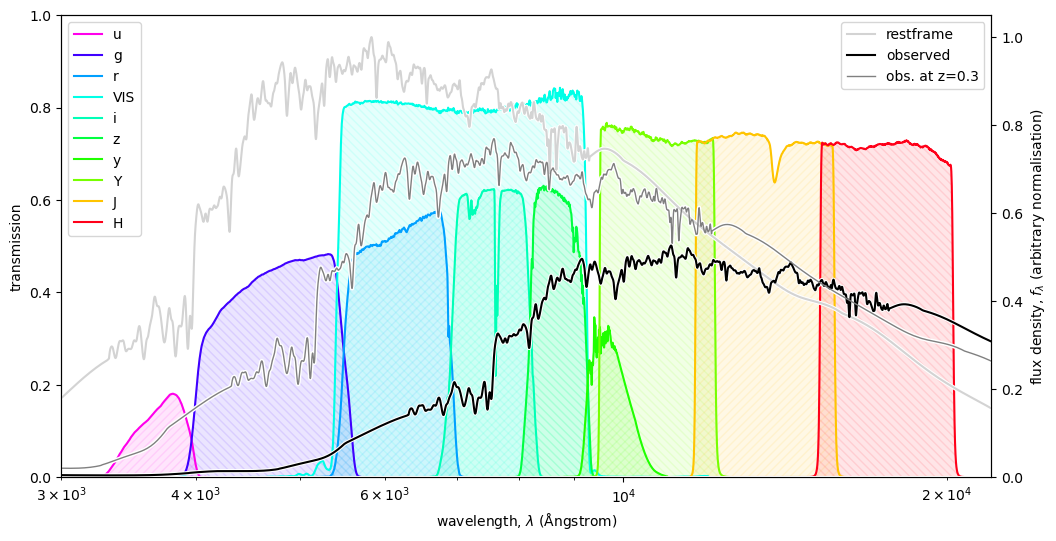

In [ ]:
sed_ax, tr_ax, cmap_norm, cmap = plot_sed(
    model.filters, wl_restframe, sed_restframe, ztrue
)
wl_zobs, flam_zobs = redshift_sed(wl_restframe, sed_restframe, zobs)
add_sed(sed_ax, wl_zobs, flam_zobs, "gray", f"obs. at z={zobs}")
sed_ax.legend();

As explained above, one approach is to calculate the kcorrections ourselves. With `zobs=0.3`, we can get a reasonable match if we shift the filters by one.

In [ ]:
filter_remap = [0, 0, 1, 2, 3, 4, 5, 6, 7, 8]
[list(filters.keys())[i] for i in filter_remap]

['u', 'u', 'g', 'r', 'VIS', 'i', 'z', 'y', 'Y', 'J']

In [ ]:
rmaggies_zobs = kc_mapped.reconstruct(redshift=zobs, coeffs=coeffs_mapped)
rmag_zobs = from_maggies(rmaggies_zobs)

In [ ]:
k_remap_obsz = rmag_zobs - rmag_restframe[filter_remap]
k_remap_obsz

array([ 1.3576291 , -0.41852233, -0.2892406 , -0.00922826,  0.09130876,
       -0.07739137, -0.08406101, -0.0197911 , -0.24651223, -0.28128509])

In [ ]:
appmags_zobs_kc = (
    absmags_restframe_kc[filter_remap] + cosmo.distmod(zobs).value + k_remap_obsz
)
appmags_zobs_kc = pd.DataFrame([appmags_zobs_kc], index=[zobs], columns=filters)
appmags_zobs_kc

,u,g,r,VIS,i,z,y,Y,J,H
0.3,22.713843,20.937692,19.592601,19.206782,19.056085,18.789599,18.585881,18.437751,18.124516,17.963073


In [ ]:
appmags_observed.loc[[zobs]]

,u,g,r,VIS,i,z,y,Y,J,H
0.3,22.735926,20.972417,19.592126,19.197447,19.04708,18.79599,18.580912,18.433036,18.134679,17.980304


This has worked very nicely.

As before, we can actually get the same result directly out of kcorrect, if we create a new kcorrect object with the observed-frame filters we want as `responses_map` and the input restframe filters as `responses_out`. 

In [ ]:
responses_out = [filter_names[i] for i in filter_remap]
responses_remap = filter_names

In [ ]:
kc_remapped = kcorrect.kcorrect.Kcorrect(
    responses=filter_names,
    cosmo=cosmo,
    responses_map=responses_remap,
    responses_out=responses_out,
    redshift_range=[0.0, 2.0],
    nredshift=201,
)

In [ ]:
k_remap_obsz = kc_remapped.kcorrect(redshift=zobs, coeffs=coeffs)
k_remap_obsz

array([ 1.3576291 , -0.41852233, -0.2892406 , -0.00922826,  0.09130876,
       -0.07739137, -0.08406101, -0.0197911 , -0.24651223, -0.28128509])

So the k-corrections match. Note that to apply these, we need to select the corresponding filters from our previously calculated absmags. However, could have just asked for these filters by specifying `response_out` in our first kcorrect object, but we also need to be careful to then change `response_map` so that it corresponds to the selected `response_out`.

For the purposes of the plot, I need to take out the distance modulus effect, where included, so we are just looking at changes due to the redshifting.

In [ ]:
delta_dmod = cosmo.distmod(ztrue).value - cosmo.distmod(zobs).value
wl_zobs_kc, sed_zobs_kc = redshift_sed(wl_restframe_kc, sed_restframe_kc, zobs)
wl_zobs_kc_mag, flux_zobs_kc_mag = mags_to_fluxes(
    appmags_zobs_kc + delta_dmod, sed_norm_kc
)
wl_zobs_mag, flux_zobs_mag = mags_to_fluxes(
    appmags_observed.loc[[zobs]] + delta_dmod, sed_norm_kc
)
wl_zobs_rmag, flux_zobs_rmag = maggies_to_fluxes(rmaggies_zobs, sed_norm_kc)

In [ ]:
flux_zobs_mag, flux_zobs_rmag, flux_zobs_kc_mag

(array([[0.09827433, 0.30354561, 0.63869305, 0.70107751, 0.71089477,
         0.67679177, 0.65368973, 0.61424092, 0.50951153, 0.34901447]]),
 array([0.09699064, 0.3030893 , 0.64003945, 0.70241974, 0.70763757,
        0.68071302, 0.64933676, 0.61006394, 0.51494065, 0.35503731]),
 array([[0.10029357, 0.31341075, 0.638414  , 0.6950756 , 0.70502273,
         0.68078739, 0.65070478, 0.6115794 , 0.51430289, 0.35459759]]))

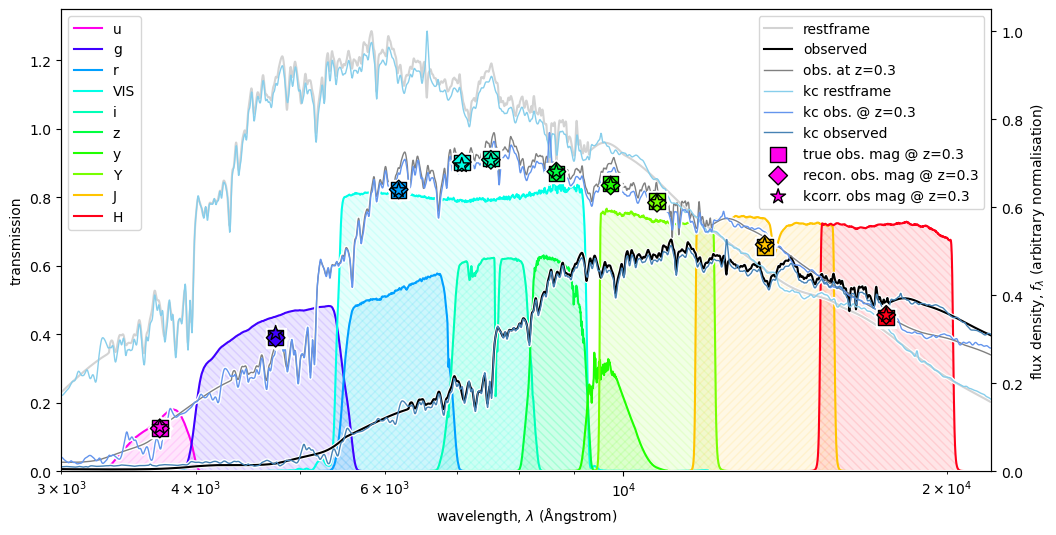

In [ ]:
sed_ax, tr_ax, cmap_norm, cmap = plot_sed(
    model.filters, wl_restframe, sed_restframe, ztrue
)

add_sed(sed_ax, wl_zobs, flam_zobs, "gray", f"obs. at z={zobs}")

add_sed(sed_ax, wl_restframe_kc, sed_restframe_kc, "skyblue", "kc restframe")
add_sed(sed_ax, wl_zobs_kc, sed_zobs_kc, "cornflowerblue", f"kc obs. @ z={zobs}")
add_sed(sed_ax, wl_observed_kc, sed_observed_kc, "steelblue", "kc observed")

add_mag(sed_ax, wl_zobs_mag, flux_zobs_mag, "s", f"true obs. mag @ z={zobs}")
add_mag(sed_ax, wl_zobs_rmag, flux_zobs_rmag, "D", f"recon. obs. mag @ z={zobs}", s=90)
add_mag(sed_ax, wl_zobs_kc_mag, flux_zobs_kc_mag, "*", f"kcorr. obs mag @ z={zobs}")

tr_ax.set_ylim(ymax=1.35)
sed_ax.legend();

Lovely!

## Summary

Now we just need to distill this down to the essentials for use in Callum's code.

Above we've used very simple mappings, but in practice we will need to find the optimum for each combination of `ztrue` and `zobs`.

In [ ]:
filter_wl_rest = np.array([filt.mean for filt in model.filters.values()])

In [ ]:
def get_filter_maps(ztrue, zobs, filter_wl_rest):
    filter_wl_ztrue = filter_wl_rest / (1 + ztrue)
    filter_wl_zobs = filter_wl_rest / (1 + zobs)
    filter_rest_ztrue = abs(filter_wl_rest - filter_wl_ztrue[:, None]).argmin(axis=0)
    filter_zobs_rest = abs(filter_wl_zobs - filter_wl_rest[:, None]).argmin(axis=0)
    filter_zobs_ztrue = abs(filter_wl_zobs - filter_wl_ztrue[:, None]).argmin(axis=0)
    return filter_rest_ztrue, filter_zobs_rest, filter_zobs_ztrue

In [ ]:
filter_rest_ztrue, filter_ztrue_zobs, filter_rest_zobs = get_filter_maps(ztrue, zobs, filter_wl_rest)
filter_rest_ztrue, filter_ztrue_zobs, filter_rest_zobs

(array([3, 5, 7, 8, 8, 9, 9, 9, 9, 9]),
 array([0, 0, 1, 1, 2, 3, 4, 5, 7, 8]),
 array([1, 3, 5, 7, 7, 8, 8, 9, 9, 9]))

Here are three equivalent implementations.
* `redshift_appmags` is my preferred version as it solves the problem most directly and accurately,
* `redshift_appmags_via_rest` is my original approach,
* `redshift_appmags_via_rest_two_kc` is Callum's approach which produces identical output to `_via_rest`, but is slower.

In [ ]:
def redshift_appmags(appmags, ztrue, zobs, filter_names, filter_wl_rest, cosmo):
    """Transform observed apparent magnitudes from one redshift to another.

    Given `appmags` apparent magnitudes corresponding to the filters
    in `filter_names` for objects observed at `ztrue`, calculate the
    apparent magnitudes that would be observed if the same objects
    were observed at a redshift of `zobs`. There is no SED evolution.

    This version directly determined the k-corrections from observed
    ztrue to zobs, without going via the restframe.

    Parameters
    ----------
    appmags : array_like
        An (n, m) array of apparent magnitudes for n objects
        observed in m filters.
    ztrue : float
        The true redshift of the objects (all must be at the same redshift).
    zobs : float
        The new redshift at which to estimate the apparent magnitudes.
    filter_names: list of str
        The names of the m filters, for passing to kcorrect.
    filter_wl_rest: array_like
        The restframe wavelengths of the m filters.
    cosmo: astropy.Cosmology
        Used to determine the distance modulus.

    Returns
    -------
    array_like
        An (n, m) array of the new apparent magnitudes if the input objects
        were observed at `zobs`.

    """
    _, _, filter_zobs_ztrue = get_filter_maps(ztrue, zobs, filter_wl_rest)
    kc = kcorrect.kcorrect.Kcorrect(
        responses=filter_names,
        cosmo=cosmo,
        redshift_range=[0.0, 2.0],
        nredshift=201,
    )
    appmags = np.atleast_2d(appmags)
    ngal = len(appmags)
    maggies = to_maggies(appmags)
    ztrue = ztrue * np.ones(ngal)
    zobs = zobs * np.ones(ngal)
    ivar = np.ones_like(maggies) / (maggies.min() / 1000) ** 2
    coeffs = kc.fit_coeffs(redshift=ztrue, maggies=maggies, ivar=ivar)
    rmaggies = kc.reconstruct(redshift=ztrue, coeffs=coeffs)
    rmag = from_maggies(rmaggies)
    rmaggies_zobs = kc.reconstruct(redshift=zobs, coeffs=coeffs)
    rmag_zobs = from_maggies(rmaggies_zobs)
    k_to_obs = rmag_zobs - rmag[:, filter_zobs_ztrue]
    distmod_ztrue = cosmo.distmod(ztrue).value
    distmod_zobs = cosmo.distmod(zobs).value
    delta_distmod = (distmod_zobs - distmod_ztrue)[:, None]
    appmags_zobs = appmags[:, filter_zobs_ztrue] + delta_distmod + k_to_obs
    df_idx = pd.MultiIndex.from_tuples(
        list(zip(zobs, range(ngal))), names=["zobs", "object"]
    )
    return pd.DataFrame(appmags_zobs, index=df_idx, columns=filter_names)

In [ ]:
def redshift_appmags_via_rest(appmags, ztrue, zobs, filter_names, filter_wl_rest, cosmo):
    """Transform observed apparent magnitudes from one redshift to another.

    Given `appmags` apparent magnitudes corresponding to the filters
    in `filter_names` for objects observed at `ztrue`, calculate the
    apparent magnitudes that would be observed if the same objects
    were observed at a redshift of `zobs`. There is no SED evolution.

    This version calculates intermediate restframe absmags.

    Parameters
    ----------
    appmags : array_like
        An (n, m) array of apparent magnitudes for n objects
        observed in m filters.
    ztrue : float
        The true redshift of the objects (all must be at the same redshift).
    zobs : float
        The new redshift at which to estimate the apparent magnitudes.
    filter_names: list of str
        The names of the m filters, for passing to kcorrect.
    filter_wl_rest: array_like
        The restframe wavelengths of the m filters.
    cosmo: astropy.Cosmology
        Used to determine the distance modulus.

    Returns
    -------
    array_like
        An (n, m) array of the new apparent magnitudes if the input objects
        were observed at `zobs`.

    """
    filter_rest_ztrue, filter_zobs_rest, _ = get_filter_maps(ztrue, zobs, filter_wl_rest)
    responses_map = [filter_names[i] for i in filter_rest_ztrue]
    kc = kcorrect.kcorrect.Kcorrect(
        responses=filter_names,
        cosmo=cosmo,
        responses_map=responses_map,
        redshift_range=[0.0, 2.0],
        nredshift=201,
    )
    appmags = np.atleast_2d(appmags)
    ngal = len(appmags)
    maggies = to_maggies(appmags)
    ztrue = ztrue * np.ones(ngal)
    zobs = zobs * np.ones(ngal)
    ivar = np.ones_like(maggies) / (maggies.min() / 1000) ** 2
    coeffs = kc.fit_coeffs(redshift=ztrue, maggies=maggies, ivar=ivar)
    absmags = kc.absmag(redshift=ztrue, maggies=maggies, ivar=ivar, coeffs=coeffs)
    rmaggies_rest = kc.reconstruct(redshift=ztrue * 0, coeffs=coeffs)
    rmag_rest = from_maggies(rmaggies_rest)
    rmaggies_zobs = kc.reconstruct(redshift=zobs, coeffs=coeffs)
    rmag_zobs = from_maggies(rmaggies_zobs)
    k_remap = rmag_zobs - rmag_rest[:, filter_zobs_rest]
    distmod = cosmo.distmod(zobs).value[:, None]
    appmags_zobs = absmags[:, filter_zobs_rest] + distmod + k_remap
    df_idx = pd.MultiIndex.from_tuples(
        list(zip(zobs, range(ngal))), names=["zobs", "object"]
    )
    return pd.DataFrame(appmags_zobs, index=df_idx, columns=filter_names)

In [ ]:
def redshift_appmags_via_rest_two_kc(appmags, ztrue, zobs, filter_names, filter_wl_rest, cosmo):
    """Transform observed apparent magnitudes from one redshift to another.

    Given `appmags` apparent magnitudes corresponding to the filters
    in `filter_names` for objects observed at `ztrue`, calculate the
    apparent magnitudes that would be observed if the same objects
    were observed at a redshift of `zobs`. There is no SED evolution.

    This version calculates intermediate restframe absmags and uses
    two kcorrect objects, so is significantly slower.

    Parameters
    ----------
    appmags : array_like
        An (n, m) array of apparent magnitudes for n objects
        observed in m filters.
    ztrue : float
        The true redshift of the objects (all must be at the same redshift).
    zobs : float
        The new redshift at which to estimate the apparent magnitudes.
    filter_names: list of str
        The names of the m filters, for passing to kcorrect.
    filter_wl_rest: array_like
        The restframe wavelengths of the m filters.
    cosmo: astropy.Cosmology
        Used to determine the distance modulus.

    Returns
    -------
    array_like
        An (n, m) array of the new apparent magnitudes if the input objects
        were observed at `zobs`.

    """
    filter_rest_ztrue, filter_zobs_rest, _ = get_filter_maps(ztrue, zobs, filter_wl_rest)
    responses_out = [filter_names[i] for i in filter_zobs_rest]
    # as we are specifying responses_out, we need the mapping to match
    filter_rest_ztrue = filter_rest_ztrue[filter_zobs_rest]
    responses_map = [filter_names[i] for i in filter_rest_ztrue]
    kc_to_rest = kcorrect.kcorrect.Kcorrect(
        responses=filter_names,
        cosmo=cosmo,
        responses_map=responses_map,
        responses_out=responses_out,
        redshift_range=[0.0, 2.0],
        nredshift=201,
    )
    kc_to_obs = kcorrect.kcorrect.Kcorrect(
        responses=filter_names,
        cosmo=cosmo,
        responses_map=filter_names,
        responses_out=responses_out,
        redshift_range=[0.0, 2.0],
        nredshift=201,
    )
    appmags = np.atleast_2d(appmags)
    ngal = len(appmags)
    maggies = to_maggies(appmags)
    ztrue = ztrue * np.ones(ngal)
    zobs = zobs * np.ones(ngal)
    ivar = np.ones_like(maggies) / (maggies.min() / 1000) ** 2
    coeffs = kc_to_rest.fit_coeffs(redshift=ztrue, maggies=maggies, ivar=ivar)
    absmags = kc_to_rest.absmag(redshift=ztrue, maggies=maggies, ivar=ivar, coeffs=coeffs)
    k = kc_to_obs.kcorrect(redshift=zobs, coeffs=coeffs)
    distmod = cosmo.distmod(zobs).value[:, None]
    appmags_zobs = absmags + distmod + k
    df_idx = pd.MultiIndex.from_tuples(
        list(zip(zobs, range(ngal))), names=["zobs", "object"]
    )
    return pd.DataFrame(appmags_zobs, index=df_idx, columns=filter_names)

Let's check it works...

We'll use the observed mags for our ezgal model at z=0.9, and copy them three times to check we can feed the function multiple objects.

In [ ]:
appmags = appmags_observed.loc[ztrue].to_numpy()
appmags = appmags * np.ones((3, 1))
appmags

array([[28.47849258, 26.43516115, 24.12720457, 23.04361904, 23.03715968,
        22.16391186, 21.82878304, 21.56292339, 21.11694495, 20.71391856],
       [28.47849258, 26.43516115, 24.12720457, 23.04361904, 23.03715968,
        22.16391186, 21.82878304, 21.56292339, 21.11694495, 20.71391856],
       [28.47849258, 26.43516115, 24.12720457, 23.04361904, 23.03715968,
        22.16391186, 21.82878304, 21.56292339, 21.11694495, 20.71391856]])

Here we go, you don't have to concatenate the results, and you could edit the function to avoid creating a DataFrame if you prefer. It takes a few seconds, but most of this is spend setting up the kcorrect grids, so it shouldn't take much longer to run on large numbers of galaxies.

In [ ]:
%%time
kc_appmags = pd.concat(
    [
        redshift_appmags(appmags, ztrue, z, filter_names, filter_wl_rest, cosmo)
        for z in zs
    ]
)

CPU times: user 18.5 s, sys: 216 ms, total: 18.7 s
Wall time: 18.9 s


In [ ]:
%%time
kc_appmags_via_rest = pd.concat(
    [
        redshift_appmags_via_rest(appmags, ztrue, z, filter_names, filter_wl_rest, cosmo)
        for z in zs
    ]
)

CPU times: user 18.1 s, sys: 197 ms, total: 18.3 s
Wall time: 18.5 s


In [ ]:
%%time
kc_appmags_via_rest_two_kc = pd.concat(
    [
        redshift_appmags_via_rest_two_kc(appmags, ztrue, z, filter_names, filter_wl_rest, cosmo)
        for z in zs
    ]
)

CPU times: user 1min 19s, sys: 973 ms, total: 1min 20s
Wall time: 1min 20s


We can limit to the Euclid bands like this...

In [ ]:
euclid_colnames = [c for c in kc_appmags.columns if "Euclid" in c]
kc_appmags[euclid_colnames]

Euclid-VIS   Euclid-Y   Euclid-J   Euclid-H
zobs object                                             
0.3  0        19.193088  18.441793  18.124519  17.963077
     1        19.193088  18.441793  18.124519  17.963077
     2        19.193088  18.441793  18.124519  17.963077
0.6  0        21.407998  20.324898  19.956769  19.631798
     1        21.407998  20.324898  19.956769  19.631798
     2        21.407998  20.324898  19.956769  19.631798
0.9  0        23.043619  21.562923  21.116945  20.713919
     1        23.043619  21.562923  21.116945  20.713919
     2        23.043619  21.562923  21.116945  20.713919
1.2  0        24.559526  22.556538  21.992209  21.557445
     1        24.559526  22.556538  21.992209  21.557445
     2        24.559526  22.556538  21.992209  21.557445
1.5  0        25.985848  23.542250  22.731122  22.214960
     1        25.985848  23.542250  22.731122  22.214960
     2        25.985848  23.542250  22.731122  22.214960
1.8  0        27.131666  24.618839  23.425284  22.784537
     1        27.131666  24.618839  23.425284  22.784537
     2        27.131666  24.618839  23.425284  22.784537

The two `via_rest` versions produce identical output.

In [ ]:
np.allclose(kc_appmags_via_rest_two_kc, kc_appmags_via_rest)

True

The preferred version and the `via_rest` versions differ a bit, especially in the blue and at high observed redshifts, due to their different approaches.

In [ ]:
kc_appmags.xs(0, level="object") - kc_appmags_via_rest.xs(0, level="object")

,lsst2023-u,lsst2023-g,lsst2023-r,Euclid-VIS,lsst2023-i,lsst2023-z,lsst2023-y,Euclid-Y,Euclid-J,Euclid-H
zobs,,,,,,,,,,
0.3,0.104186,0.000002,0.000003,-0.006303,-1.068706e-07,0.000002,8.739224e-07,2.013139e-06,8.210459e-07,1.923732e-06
0.6,0.104186,-0.039118,0.008652,0.000003,3.134006e-06,-0.006303,-1.068706e-07,1.946806e-06,2.013139e-06,8.210459e-07
0.9,0.899273,0.104186,-0.039118,0.000002,8.652264e-03,0.000003,-4.135848e-03,-1.068706e-07,1.946806e-06,1.774720e-06
1.2,0.899273,0.899273,0.104186,-0.039118,-3.911832e-02,0.008652,3.134006e-06,-4.135848e-03,-1.068706e-07,8.739224e-07
1.5,0.899273,0.899273,0.104186,0.104186,-3.911832e-02,-0.039118,8.652264e-03,3.134006e-06,-6.302642e-03,1.946806e-06
1.8,0.899273,0.899273,0.899273,0.104186,1.041864e-01,-0.039118,-3.911832e-02,1.611652e-06,3.134006e-06,-1.068706e-07


We can compare to the magnitudes determined directly from the input SED.

In [ ]:
appmags_check = appmags_observed.copy()
appmags_check.columns = filter_names
appmags_check = appmags_check.rename_axis("zobs")
appmags_check

,lsst2023-u,lsst2023-g,lsst2023-r,Euclid-VIS,lsst2023-i,lsst2023-z,lsst2023-y,Euclid-Y,Euclid-J,Euclid-H
zobs,,,,,,,,,,
0.3,22.735926,20.972417,19.592126,19.197447,19.047080,18.795990,18.580912,18.433036,18.134679,17.980304
0.6,26.285682,23.807928,22.261704,21.403453,21.165038,20.783366,20.501009,20.327918,19.950634,19.645619
0.9,28.478493,26.435161,24.127205,23.043619,23.037160,22.163912,21.828783,21.562923,21.116945,20.713919
1.2,29.721477,28.334265,25.888145,24.596410,24.478248,23.737537,22.936869,22.555331,21.993130,21.551666
1.5,30.349555,29.610272,27.753692,25.860528,25.757753,24.881657,24.308851,23.544390,22.728827,22.215356
1.8,30.703686,30.764565,29.039191,27.049565,27.368076,25.877711,25.244337,24.620337,23.422385,22.786535


In [ ]:
kc_appmags.xs(0, level="object")

,lsst2023-u,lsst2023-g,lsst2023-r,Euclid-VIS,lsst2023-i,lsst2023-z,lsst2023-y,Euclid-Y,Euclid-J,Euclid-H
zobs,,,,,,,,,,
0.3,22.857150,20.976814,19.593862,19.193088,19.049782,18.787027,18.585475,18.441793,18.124519,17.963077
0.6,26.123894,23.796475,22.267974,21.407998,21.165652,20.784756,20.502415,20.324898,19.956769,19.631798
0.9,28.478493,26.435161,24.127205,23.043619,23.037160,22.163912,21.828783,21.562923,21.116945,20.713919
1.2,29.691330,28.763546,26.003034,24.559526,24.473432,23.733438,22.934784,22.556538,21.992209,21.557445
1.5,30.664445,29.672995,27.713406,25.985848,25.749834,24.881476,24.305814,23.542250,22.731122,22.214960
1.8,31.204353,30.563341,29.515551,27.131666,27.435650,25.875362,25.242128,24.618839,23.425284,22.784537


In [ ]:
error = kc_appmags.xs(0, level="object") - appmags_check
error

,lsst2023-u,lsst2023-g,lsst2023-r,Euclid-VIS,lsst2023-i,lsst2023-z,lsst2023-y,Euclid-Y,Euclid-J,Euclid-H
zobs,,,,,,,,,,
0.3,0.121225,0.004397,0.001736,-0.004358,0.002702,-0.008964,0.004563,0.008757,-0.010160,-0.017227
0.6,-0.161787,-0.011453,0.006270,0.004545,0.000614,0.001390,0.001406,-0.003020,0.006135,-0.013821
0.9,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1.2,-0.030147,0.429281,0.114889,-0.036884,-0.004815,-0.004100,-0.002085,0.001207,-0.000921,0.005779
1.5,0.314889,0.062723,-0.040286,0.125320,-0.007918,-0.000181,-0.003037,-0.002140,0.002294,-0.000395
1.8,0.500667,-0.201223,0.476359,0.082101,0.067574,-0.002349,-0.002209,-0.001498,0.002899,-0.001999


So, the error in the Euclid bands is typically a few hundredths of a magnitude, although the error for VIS can reach 0.2 mag. 

The previous `via_rest` methods perfoms slightly worse overall, although in this example it does better for VIS at high-z.

In [ ]:
error = kc_appmags_via_rest.xs(0, level="object") - appmags_check
error

,lsst2023-u,lsst2023-g,lsst2023-r,Euclid-VIS,lsst2023-i,lsst2023-z,lsst2023-y,Euclid-Y,Euclid-J,Euclid-H
zobs,,,,,,,,,,
0.3,0.017038,0.004396,0.001733,0.001944,0.002702,-0.008965,0.004562,8.755341e-03,-0.010161,-0.017229
0.6,-0.265974,0.027665,-0.002382,0.004542,0.000611,0.007693,0.001407,-3.021872e-03,0.006133,-0.013822
0.9,-0.899273,-0.104186,0.039118,-0.000002,-0.008652,-0.000003,0.004136,1.068706e-07,-0.000002,-0.000002
1.2,-0.929420,-0.469992,0.010703,0.002235,0.034303,-0.012752,-0.002088,5.342593e-03,-0.000921,0.005779
1.5,-0.584383,-0.836549,-0.144472,0.021133,0.031200,0.038938,-0.011689,-2.142769e-03,0.008597,-0.000397
1.8,-0.398605,-1.100496,-0.422913,-0.022085,-0.036613,0.036770,0.036910,-1.499658e-03,0.002895,-0.001999
